# Topological NMF Demo


# Setup

Make sure the `TopNMF` package and its optional plotting dependencies are installed in the active environment before running the rest of the notebook.


In [1]:
%matplotlib widget
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from TopNMF import *


# Time Series

## Generate Synthetic Signals

We create a small collection of normalized triangle wave signals to mimic multiple sensors.


In [ ]:
np.random.seed(42)
t = create_time_array(start=0, stop=2 * np.pi, n_points=100)
signals_dict = generate_triangle_signals(t)
signals_dict = normalize_signals(signals_dict, method="max")

X_list = [sig for sig in signals_dict.values()]
X = np.vstack(X_list)

print(f"Generated {len(X_list)} signals with shape {X.shape}")


NameError: name 'np' is not defined

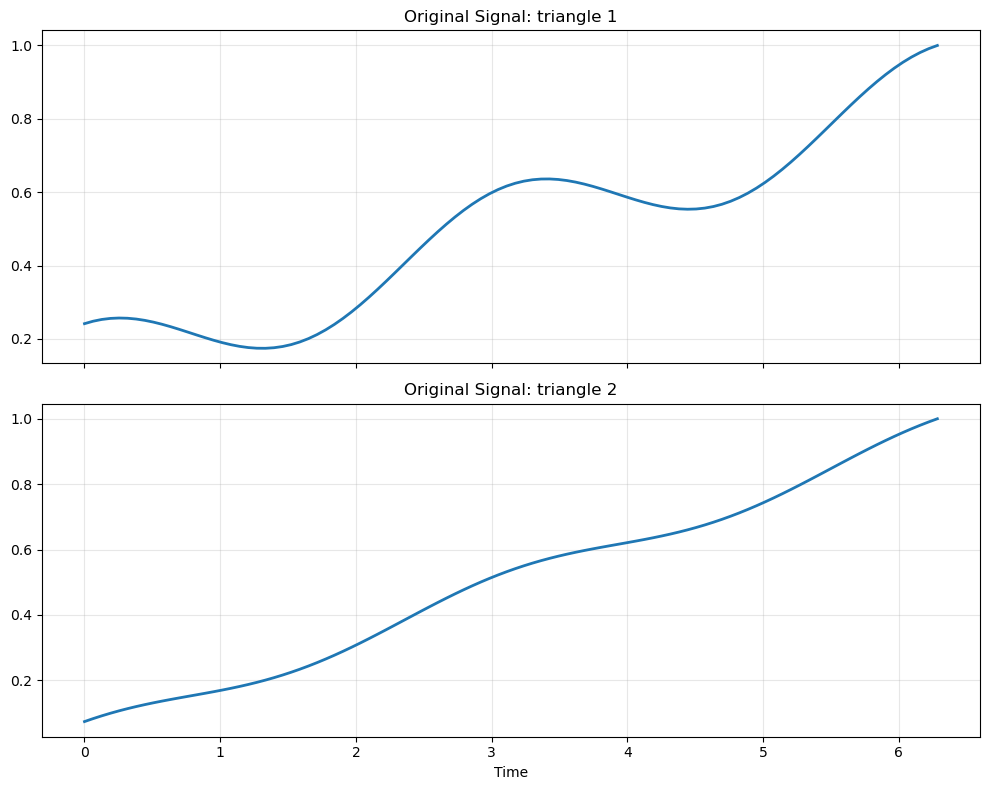

In [3]:
fig, axes = plt.subplots(len(signals_dict), 1, figsize=(10, 8), sharex=True)
if len(signals_dict) == 1:
    axes = [axes]
for ax, (name, sig) in zip(axes, signals_dict.items()):
    ax.plot(t, sig, linewidth=2)
    ax.set_title(f"Original Signal: {name}")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time")
fig.tight_layout()
plt.show()


## 2. Fit Topological NMF Model

We instantiate `TopologicalNMF` with two components and train it with a small topological loss weight.


In [4]:
n_components = 2
model = TopologicalNMF(
    n_components=n_components,
    device="cpu",
    random_state=42
)

model.fit(
    X,
    n_iterations=10000,
    lr=0.005,
    lambda_apx=1.0,
    lambda_top=0.001,
    lambda_spa_V=0.0,
    lambda_spa_W=0.0,
    lambda_tv=0.0,
    target_periodicity=[1.0, 0.0],
    M=4,
    init_method="nndsvda",
    verbose=True
)

print("Model fitted successfully!")


  0%|          | 0/10000 [00:00<?, ?it/s]

Model fitted successfully!


## Visualize Results

The following cells inspect the learned basis signals and reconstructions.


In [12]:
V = model.get_components()
W = model.transform(X)
X_reconstructed = model.inverse_transform()

print(f"Components shape: {V.shape}")
print(f"Coefficient matrix shape: {W.shape}")

M = 4
tau = int(len(t) / (2 * (M + 1)))
for i in range(n_components):
    score = compute_periodicity_score(V[i], dim=M + 1, tau=tau)
    print(f"Basis {i + 1} persistence score: {score:.4f}")


Components shape: (2, 100)
Coefficient matrix shape: (2, 2)
Basis 1 persistence score: 0.9195
Basis 2 persistence score: 0.0008


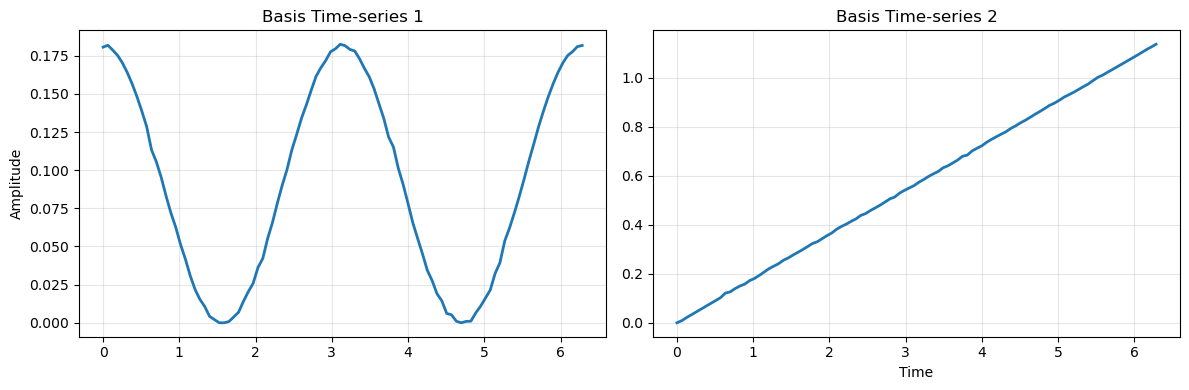

In [6]:
fig, axes = plt.subplots(1, n_components, figsize=(12, 4), sharex=True)
if n_components == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(t, V[i], linewidth=2)
    ax.set_title(f"Basis Time-series {i + 1}")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time")
fig.tight_layout()
plt.show()


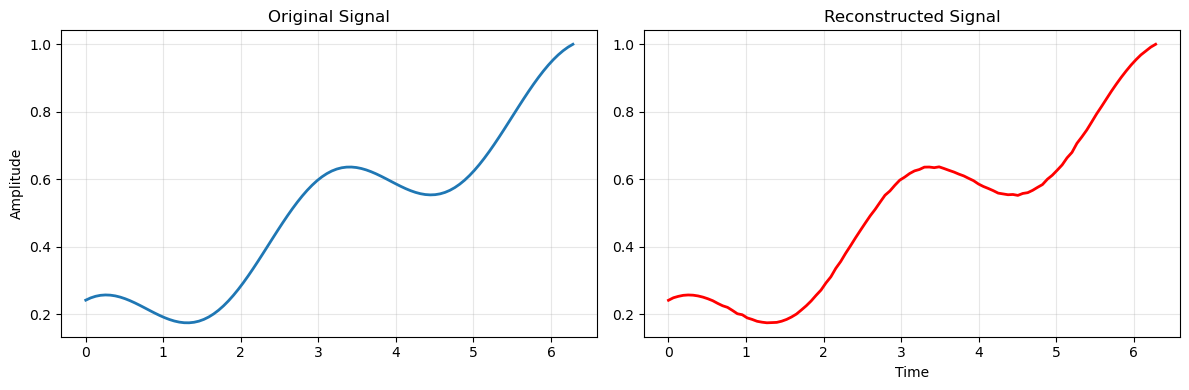

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(t, X[0], linewidth=2)
axes[0].set_title("Original Signal")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].plot(t, X_reconstructed[0], linewidth=2, color="red")
axes[1].set_title("Reconstructed Signal")
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Time")
fig.tight_layout()
plt.show()


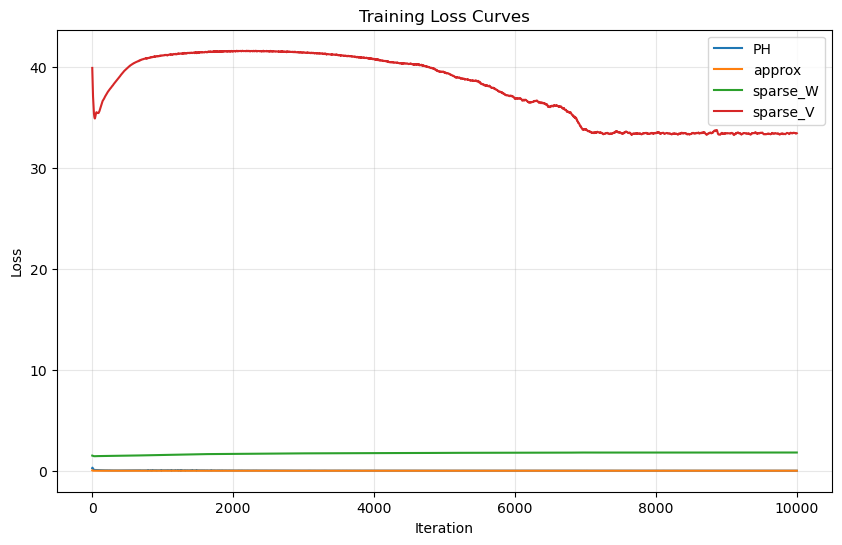

In [8]:
losses = model.get_losses()
fig, ax = plt.subplots(figsize=(10, 6))
plot_loss(losses, ax=ax)
ax.set_title("Training Loss Curves")
plt.show()


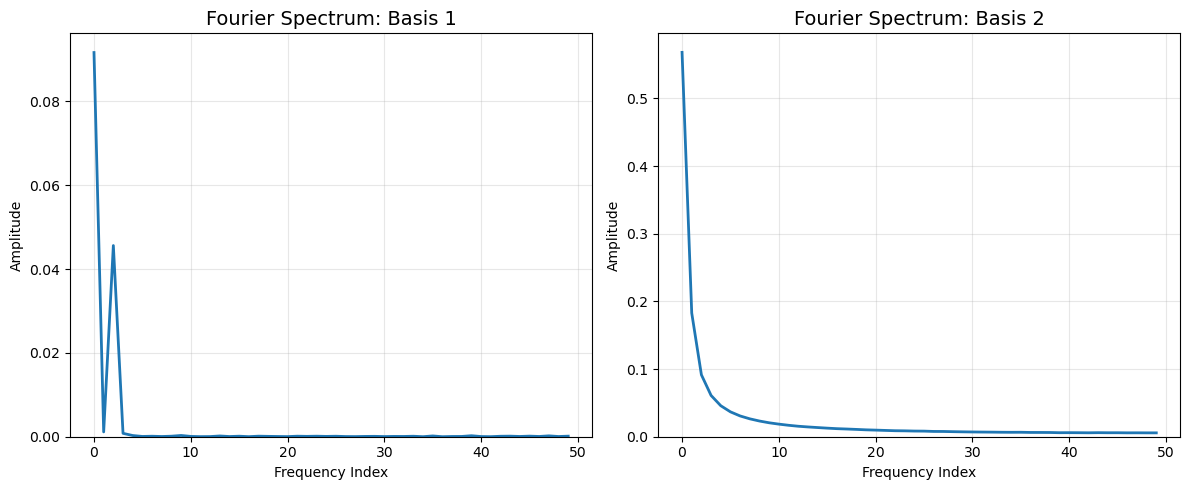

In [9]:
fig, _ = plot_fourier_spectrum(
    [V[i] for i in range(n_components)],
    labels=[f"Basis {i + 1}" for i in range(n_components)],
    n_components=50,
    figsize=(12, 5)
)
plt.show()


In [14]:
reconstruction_error = np.mean((X - X_reconstructed) ** 2)
print(f"Mean squared reconstruction error: {reconstruction_error:.6f}")

for i, (original, reconstructed) in enumerate(zip(X, X_reconstructed), start=1):
    mse = np.mean((original - reconstructed) ** 2)
    print(f"  Signal {i} MSE: {mse:.6f}")

print("\nCoefficient matrix W:", W)


Mean squared reconstruction error: 0.000001
  Signal 1 MSE: 0.000001
  Signal 2 MSE: 0.000001

Coefficient matrix W: [[1.3353404  0.66680896]
 [0.4125589  0.8143431 ]]


# Image

(400, 4096)


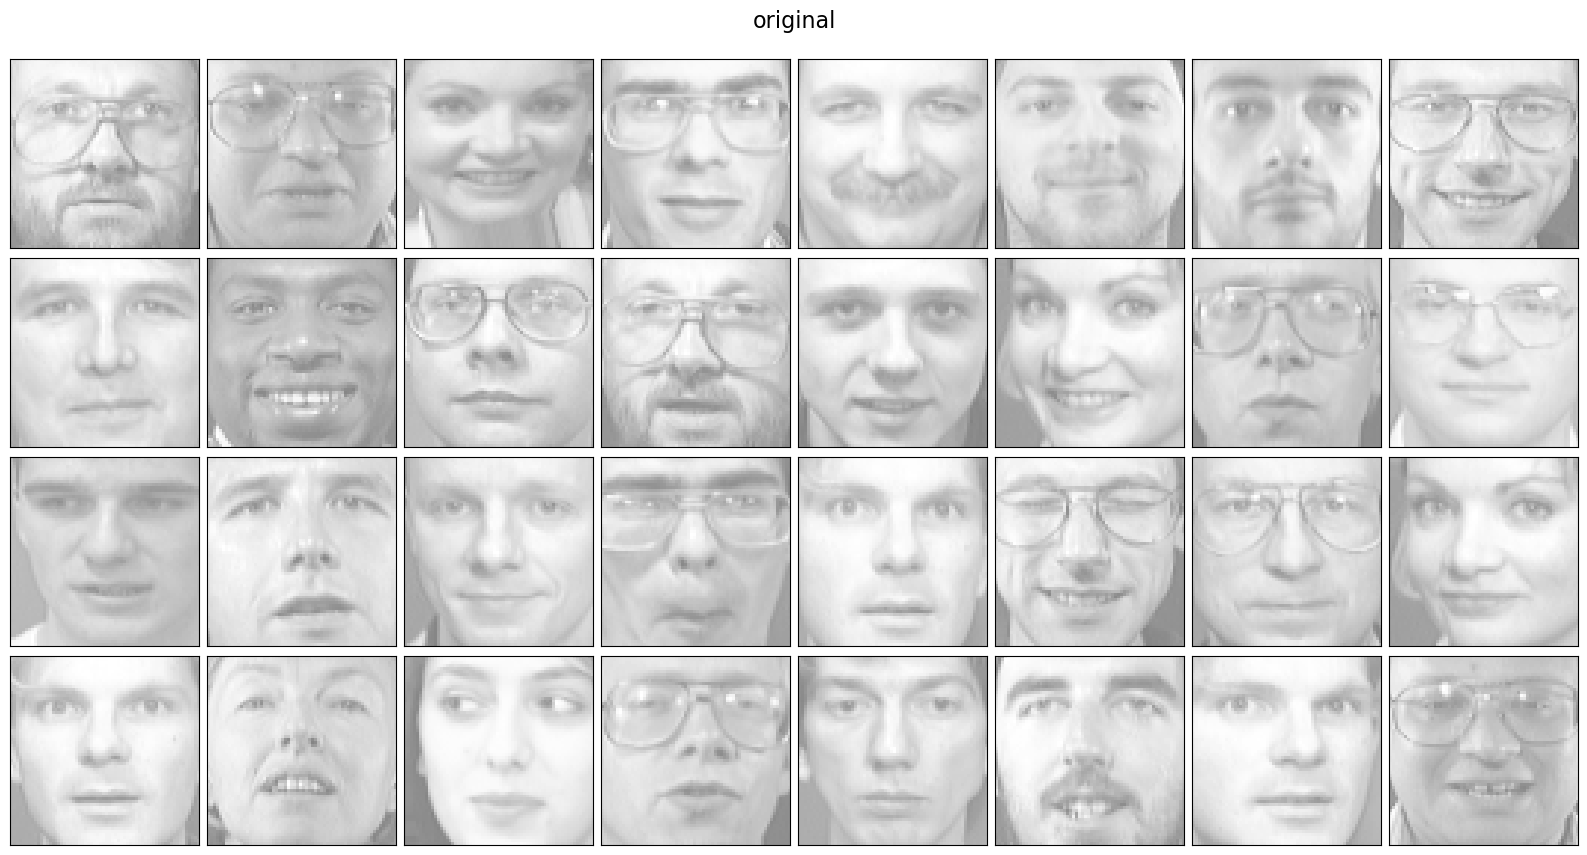

In [5]:
from cubical_complex import CubicalComplex
import numpy as np

# face dataset
from sklearn.datasets import fetch_olivetti_faces
X, _ = fetch_olivetti_faces(return_X_y=True, shuffle=True)
n_samples, n_features = X.shape
image_shape = (64, 64)
print(X.shape)
plot_gallery(X.reshape(-1,*image_shape),title="original",n_row=4, n_col = 8)
plt.show()

In [8]:
cubical_complex = CubicalComplex(
    superlevel=True,
    dim=len(image_shape),
    mode='V'
)

model = TopologicalNMF(
    n_components=32,
    device='cpu',
    complex=cubical_complex,
    ph_loss_fn=ph_sparsity_loss,
    data_shape=image_shape,
    use_embedding=False
)

model.fit(
    X,
    n_iterations=100,
    lr=0.001,
    lambda_top=0.5,
    lambda_spa_W=0.001,
    weight_decay=0.01,
    PH_dims=[0, 1],
    start_epoch_topological=0
)

  0%|          | 0/100 [00:00<?, ?it/s]

Components shape: (32, 64, 64)
Coefficient matrix shape: (400, 32)


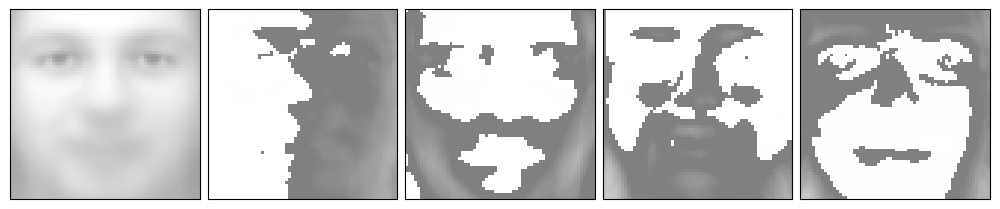

In [7]:
V = model.get_components()
V = V.reshape(-1,*image_shape)
W = model.transform(X)
X_reconstructed = model.inverse_transform()

print(f"Components shape: {V.shape}")
print(f"Coefficient matrix shape: {W.shape}")

plot_gallery(V, n_row=1)
plt.show()

### Target Diagram Loss

In [ ]:

from topological_nmf import TopologicalNMF, target_diagram_loss
from cubical_complex import CubicalComplex
import torch
import numpy as np

X = np.random.rand(40, 81)
image_shape = (9, 9)

target_PH = [
    torch.tensor([[]], dtype=torch.float, device='cpu', requires_grad=False),
    torch.tensor([[]], dtype=torch.float, device='cpu', requires_grad=False)
]

cubical_complex = CubicalComplex(superlevel=True, dim=2, mode='V')

model = TopologicalNMF(
    n_components=32,
    device='cpu',
    complex=cubical_complex,
    ph_loss_fn=target_diagram_loss,
    data_shape=image_shape,
    use_embedding=False
)

model.fit(
    X,
    n_iterations=2000,
    lr=0.05,
    lambda_top=0.5,
    target_diagrams=target_PH,
    PH_dims=[0, 1],
    start_epoch_topological=100
)

### Custom Persistent Homology Loss

In [ ]:
from topological_nmf import TopologicalNMF
import torch

def custom_ph_loss(diagrams, PH_dims, target_diagrams, device):
    loss = torch.tensor(0.0, device=device)
    for dim in PH_dims:
        PH = diagrams[dim].diagram
        if len(PH) > 0:
            pers = torch.diff(PH, dim=1).reshape(-1)
            loss -= pers.max()
    return loss

model = TopologicalNMF(
    n_components=10,
    device='cpu',
    ph_loss_fn=custom_ph_loss
)

model.fit(X, lambda_top=0.01, PH_dims=[1])
